## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
#!nvidia-smi

zsh:1: command not found: nvidia-smi


In [7]:
import torch

device = torch.device("mps")  # Use Apple Metal GPU
print(f"Using device: {device}")

Using device: mps


**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [9]:
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /Users/ma/Documents/samThesis/segment-anything/notebooks


## Install Segment Anything Model (SAM) and other dependencies

In [12]:
!pip install -q 'git+https://github.com/facebookresearch/segment-anything.git'

In [14]:
!pip install -q jupyter_bbox_widget roboflow dataclasses-json supervision==0.23.0

### Download SAM weights

In [20]:
#!mkdir -p {HOME}/weights
#!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -P {HOME}/weights

In [37]:
import os
import urllib.request
from segment_anything import sam_model_registry, SamPredictor
import torch

# Define the checkpoint URL and local path
CHECKPOINT_URL = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth"
CHECKPOINT_PATH = os.path.expanduser("~/weights/sam_vit_h.pth")

# Ensure the directory exists
os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)

# Download the model if it doesn't exist
if not os.path.exists(CHECKPOINT_PATH):
    print(f"Downloading SAM model weights from {CHECKPOINT_URL}...")
    urllib.request.urlretrieve(CHECKPOINT_URL, CHECKPOINT_PATH)
    print(f"✅ Download complete: {CHECKPOINT_PATH}")
else:
    print(f"✅ Model already exists at: {CHECKPOINT_PATH}")

# Verify the file size (SAM model should be ~2.4GB)
file_size = os.path.getsize(CHECKPOINT_PATH) / (1024**3)  # Convert bytes to GB

# Allow a small margin instead of exact 2.4GB
if file_size < 2.38:  # Adjust threshold to allow small differences
    raise ValueError(f"❌ Downloaded file seems incomplete ({file_size:.2f} GB). Try re-downloading.")
else:
    print(f"✅ Model downloaded successfully: {file_size:.2f} GB")
# Set up PyTorch MPS for Mac M1/M2
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Load the SAM model
sam = sam_model_registry["vit_h"](checkpoint=CHECKPOINT_PATH)
sam.to(device)

predictor = SamPredictor(sam)
print("✅ SAM model loaded successfully on:", device)

✅ Model already exists at: /Users/ma/weights/sam_vit_h.pth
✅ Model downloaded successfully: 2.39 GB
Using device: mps
✅ SAM model loaded successfully on: mps


In [43]:
import os

CHECKPOINT_PATH = os.path.join(HOME, "weights", "sam_vit_h_4b8939.pth")
print(CHECKPOINT_PATH, "; exist:", os.path.isfile(CHECKPOINT_PATH))

/Users/ma/Documents/samThesis/segment-anything/notebooks/weights/sam_vit_h_4b8939.pth ; exist: True


## Download Example Data

**NONE:** Let's download few example images. Feel free to use your images or videos.

In [57]:
!arch -arm64 brew install wget

==> Downloading https://ghcr.io/v2/homebrew/core/wget/manifests/1.25.0
######################################################################### 100.0%
==> Fetching dependencies for wget: libunistring, gettext, libidn2, ca-certificates and openssl@3
==> Downloading https://ghcr.io/v2/homebrew/core/libunistring/manifests/1.3
######################################################################### 100.0%
==> Fetching libunistring
==> Downloading https://ghcr.io/v2/homebrew/core/libunistring/blobs/sha256:b0d7a
######################################################################### 100.0%
==> Downloading https://ghcr.io/v2/homebrew/core/gettext/manifests/0.24
######################################################################### 100.0%
==> Fetching gettext
==> Downloading https://ghcr.io/v2/homebrew/core/gettext/blobs/sha256:bbf800d209
######################################################################### 100.0%
==> Downloading https://ghcr.io/v2/homebrew/core/libidn2/manifests/2.

In [61]:
!mkdir -p {HOME}/data

!wget -q https://media.roboflow.com/notebooks/examples/dog.jpeg -P {HOME}/data
!wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg -P {HOME}/data
!wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg -P {HOME}/data
!wget -q https://media.roboflow.com/notebooks/examples/dog-4.jpeg -P {HOME}/data

## Load Model

In [64]:
import torch

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"

In [66]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)

## Automated Mask Generation

To run automatic mask generation, provide a SAM model to the `SamAutomaticMaskGenerator` class. Set the path below to the SAM checkpoint. Running on CUDA and with the default model is recommended.

In [69]:
mask_generator = SamAutomaticMaskGenerator(sam)

In [71]:
import os

IMAGE_NAME = "dog.jpeg"
IMAGE_PATH = os.path.join(HOME, "data", IMAGE_NAME)

### Generate masks with SAM

In [152]:
"""
import cv2
import supervision as sv

image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

sam_result = mask_generator.generate(image_rgb)
"""

'\nimport cv2\nimport supervision as sv\n\nimage_bgr = cv2.imread(IMAGE_PATH)\nimage_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)\n\nsam_result = mask_generator.generate(image_rgb)\n'

In [150]:
import cv2
import supervision as sv

# Load the image
image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Print image dimensions
print(f"🔹 Original Image Size (BGR): {image_bgr.shape}")
print(f"🔹 Processed Image Size (RGB): {image_rgb.shape}")

# Generate the mask with SAM
sam_result = mask_generator.generate(image_rgb)

# Extract mask size
if sam_result and "segmentation" in sam_result[0]:
    mask_size = sam_result[0]["segmentation"].shape
    print(f"🔹 Generated Mask Size: {mask_size}")

    # Check if mask matches image size
    if mask_size != image_rgb.shape[:2]:  # Compare (height, width)
        print(f"⚠️ WARNING: Mask size {mask_size} does not match image size {image_rgb.shape[:2]}!")
else:
    print("⚠️ No masks were generated!")

🔹 Original Image Size (BGR): (1280, 720, 3)
🔹 Processed Image Size (RGB): (1280, 720, 3)
🔹 Generated Mask Size: (1280, 720)


### Output format

`SamAutomaticMaskGenerator` returns a `list` of masks, where each mask is a `dict` containing various information about the mask:

* `segmentation` - `[np.ndarray]` - the mask with `(W, H)` shape, and `bool` type
* `area` - `[int]` - the area of the mask in pixels
* `bbox` - `[List[int]]` - the boundary box of the mask in `xywh` format
* `predicted_iou` - `[float]` - the model's own prediction for the quality of the mask
* `point_coords` - `[List[List[float]]]` - the sampled input point that generated this mask
* `stability_score` - `[float]` - an additional measure of mask quality
* `crop_box` - `List[int]` - the crop of the image used to generate this mask in `xywh` format

In [80]:
print(sam_result[0].keys())

dict_keys(['segmentation', 'area', 'bbox', 'predicted_iou', 'point_coords', 'stability_score', 'crop_box'])


### Results visualisation with Supervision

As of version `0.5.0` Supervision has native support for SAM.

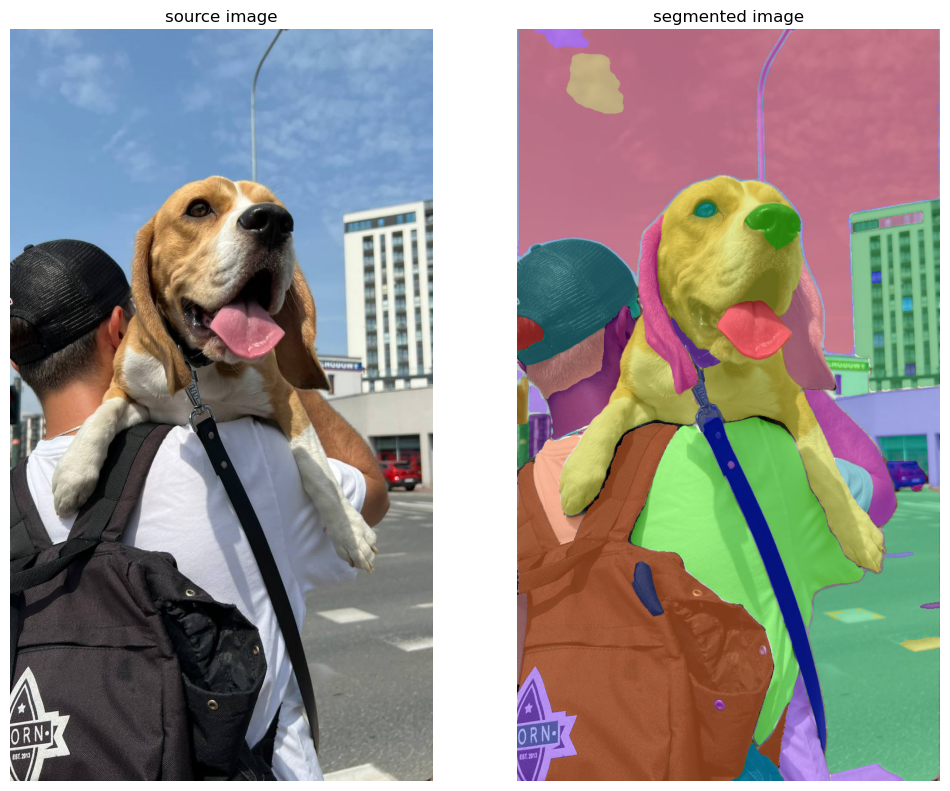

In [83]:
mask_annotator = sv.MaskAnnotator(color_lookup=sv.ColorLookup.INDEX)

detections = sv.Detections.from_sam(sam_result=sam_result)

annotated_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

sv.plot_images_grid(
    images=[image_bgr, annotated_image],
    grid_size=(1, 2),
    titles=['source image', 'segmented image']
)

### Interaction with segmentation results

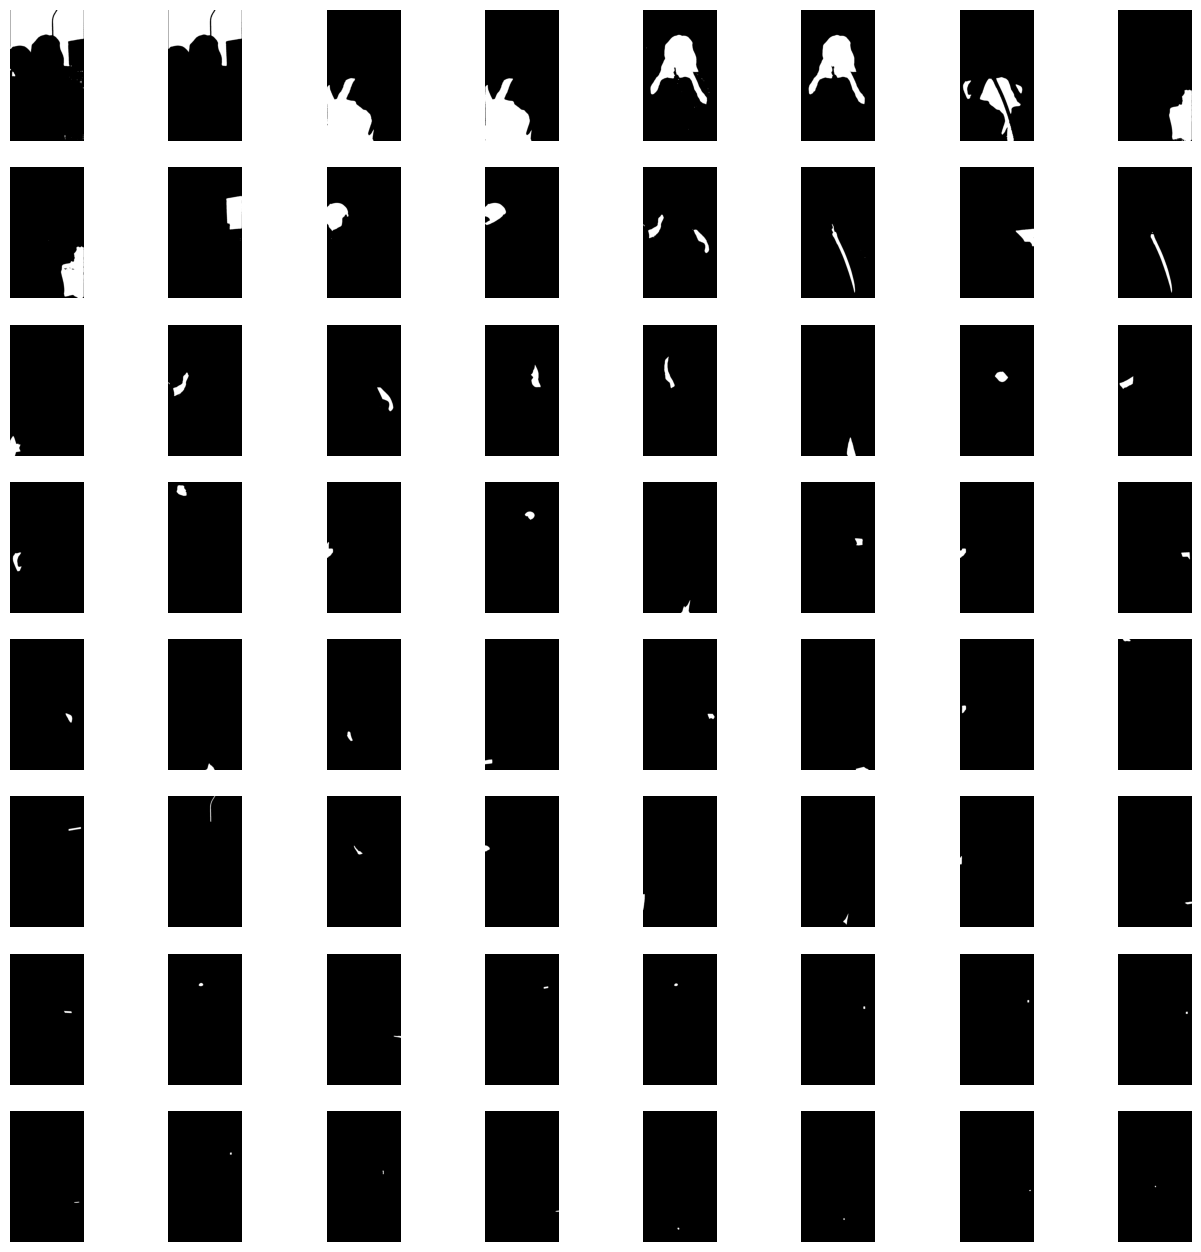

In [88]:
masks = [
    mask['segmentation']
    for mask
    in sorted(sam_result, key=lambda x: x['area'], reverse=True)
]

sv.plot_images_grid(
    images=masks,
    grid_size=(8, int(len(masks) / 8)),
    size=(16, 16)
)

## Generate Segmentation with Bounding Box

The `SamPredictor` class provides an easy interface to the model for prompting the model. It allows the user to first set an image using the `set_image` method, which calculates the necessary image embeddings. Then, prompts can be provided via the `predict` method to efficiently predict masks from those prompts. The model can take as input both point and box prompts, as well as masks from the previous iteration of prediction.

In [90]:
mask_predictor = SamPredictor(sam)

In [93]:
import os

IMAGE_NAME = "dog.jpeg"
IMAGE_PATH = os.path.join(HOME, "data", IMAGE_NAME)

### Draw Box



In [96]:
# helper function that loads an image before adding it to the widget

import base64

def encode_image(filepath):
    with open(filepath, 'rb') as f:
        image_bytes = f.read()
    encoded = str(base64.b64encode(image_bytes), 'utf-8')
    return "data:image/jpg;base64,"+encoded

**NOTE:** Execute cell below and use your mouse to draw bounding box on the image 👇

In [103]:
#IS_COLAB = True

#if IS_COLAB:
#    from google.colab import output
#    output.enable_custom_widget_manager()

#from jupyter_bbox_widget import BBoxWidget

#widget = BBoxWidget()
#widget.image = encode_image(IMAGE_PATH)
#widget

In [105]:
!pip install jupyter_bbox_widget ipywidgets

In [107]:
import sys

# Automatically detect if running in Google Colab
IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    from google.colab import output
    output.enable_custom_widget_manager()
    print("Running on Google Colab. Custom widget manager enabled.")
else:
    print("Running on Jupyter Notebook (local). Skipping Colab-specific code.")

# Import jupyter_bbox_widget
from jupyter_bbox_widget import BBoxWidget

widget = BBoxWidget()
widget.image = encode_image(IMAGE_PATH)
widget

Running on Jupyter Notebook (local). Skipping Colab-specific code.


BBoxWidget(colors=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#b…

In [109]:
widget.bboxes

[]

### Generate masks with SAM

**NOTE:** `SamPredictor.predict` method takes `np.ndarray` `box` argument in `[x_min, y_min, x_max, y_max]` format. Let's reorganise your data first

In [113]:
import numpy as np

# default_box is going to be used if you will not draw any box on image above
default_box = {'x': 68, 'y': 247, 'width': 555, 'height': 678, 'label': ''}

box = widget.bboxes[0] if widget.bboxes else default_box
box = np.array([
    box['x'],
    box['y'],
    box['x'] + box['width'],
    box['y'] + box['height']
])

In [143]:
import cv2
import numpy as np
import supervision as sv

image_bgr = cv2.imread(IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# Check and print image dimensions
print(f"Image dimensions (BGR): {image_bgr.shape}")
print(f"Image dimensions (RGB): {image_rgb.shape}")

mask_predictor.set_image(image_rgb)

masks, scores, logits = mask_predictor.predict(
    box=box,
    multimask_output=True
)
# Ensure mask and image dimensions match
if masks.shape[1:] != image_rgb.shape[:2]:  # Compare height & width
    print(f"⚠️ Warning: Mask size {masks.shape[1:]} does not match image size {image_rgb.shape[:2]}!")
else:
    print("✅ Mask and image sizes match.")

Image dimensions (BGR): (1280, 720, 3)
Image dimensions (RGB): (1280, 720, 3)
✅ Mask and image sizes match.


### Results visualisation with Supervision

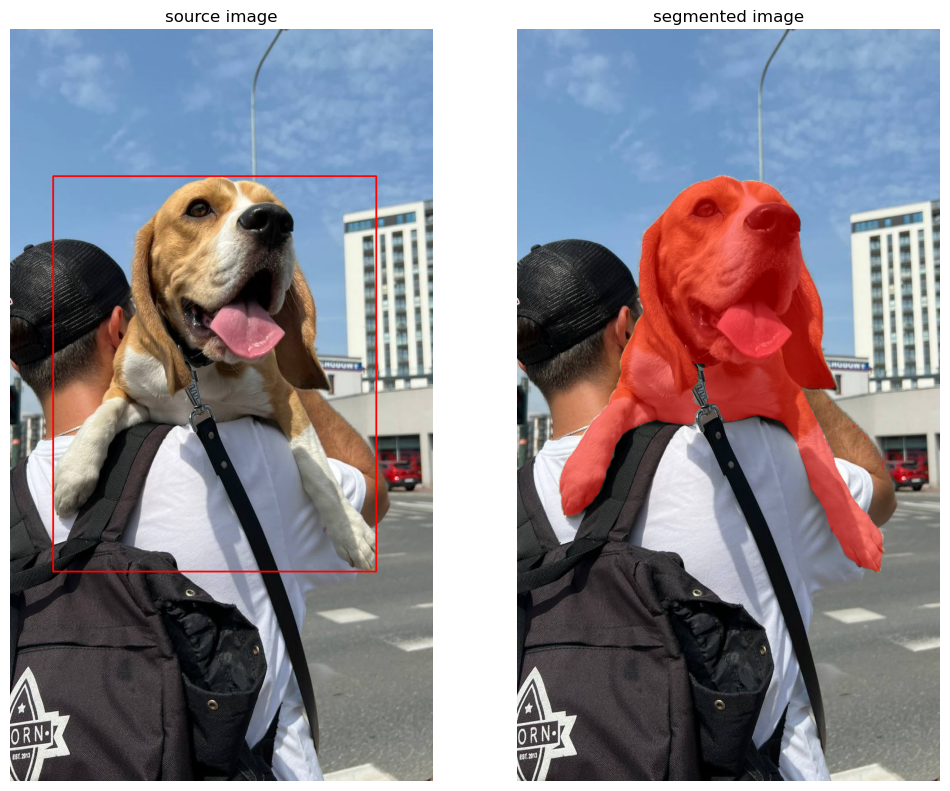

In [154]:
box_annotator = sv.BoxAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)
mask_annotator = sv.MaskAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)

detections = sv.Detections(
    xyxy=sv.mask_to_xyxy(masks=masks),
    mask=masks
)
detections = detections[detections.area == np.max(detections.area)]

source_image = box_annotator.annotate(scene=image_bgr.copy(), detections=detections)
segmented_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

sv.plot_images_grid(
    images=[source_image, segmented_image],
    grid_size=(1, 2),
    titles=['source image', 'segmented image']
)

In [156]:
# Extract bounding box and mask details
for i, det in enumerate(detections.xyxy):
    print(f"🔹 Object {i}: Bounding Box {det}, Mask Size {masks[i].shape}")

# Get image dimensions
image_height, image_width = image_rgb.shape[:2]

# Check if bounding boxes exceed image boundaries
for i, det in enumerate(detections.xyxy):
    x_min, y_min, x_max, y_max = det
    if x_max > image_width or y_max > image_height:
        print(f"⚠️ WARNING: Bounding Box {det} exceeds image dimensions {image_width}x{image_height}!")
    else:
        print(f"✅ Bounding Box {i} is within image bounds.")


🔹 Object 0: Bounding Box [ 73 250 623 923], Mask Size (1280, 720)
✅ Bounding Box 0 is within image bounds.


### Interaction with segmentation results

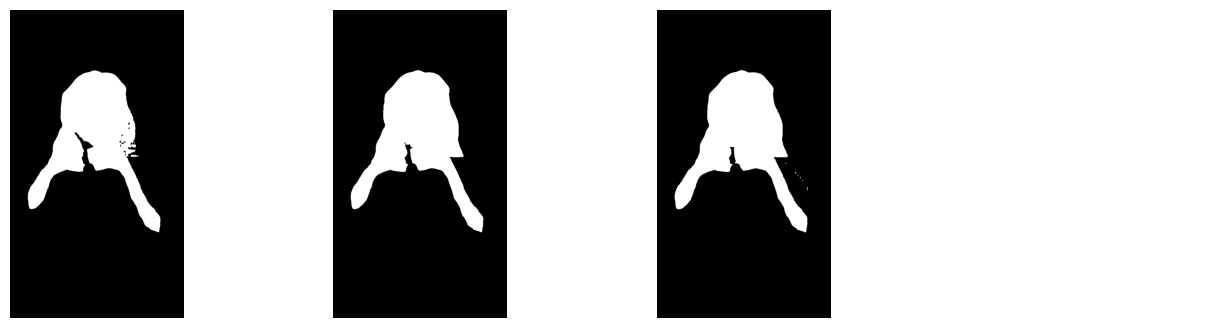

In [121]:
import supervision as v

sv.plot_images_grid(
    images=masks,
    grid_size=(1, 4),
    size=(16, 4)
)

## Segment Anything in Roboflow Universe Dataset

### Utils Supporting Dataset Processing

A couple of helper functions that, unfortunately, we have to write ourselves to facilitate the processing of COCO annotations.

In [125]:
import numpy as np
from dataclasses import dataclass
from typing import List, Tuple, Union, Optional
from dataclasses_json import dataclass_json
from supervision import Detections


@dataclass_json
@dataclass
class COCOCategory:
    id: int
    name: str
    supercategory: str


@dataclass_json
@dataclass
class COCOImage:
    id: int
    width: int
    height: int
    file_name: str
    license: int
    date_captured: str
    coco_url: Optional[str] = None
    flickr_url: Optional[str] = None


@dataclass_json
@dataclass
class COCOAnnotation:
    id: int
    image_id: int
    category_id: int
    segmentation: List[List[float]]
    area: float
    bbox: Tuple[float, float, float, float]
    iscrowd: int


@dataclass_json
@dataclass
class COCOLicense:
    id: int
    name: str
    url: str


@dataclass_json
@dataclass
class COCOJson:
    images: List[COCOImage]
    annotations: List[COCOAnnotation]
    categories: List[COCOCategory]
    licenses: List[COCOLicense]


def load_coco_json(json_file: str) -> COCOJson:
    import json

    with open(json_file, "r") as f:
        json_data = json.load(f)

    return COCOJson.from_dict(json_data)


class COCOJsonUtility:
    @staticmethod
    def get_annotations_by_image_id(coco_data: COCOJson, image_id: int) -> List[COCOAnnotation]:
        return [annotation for annotation in coco_data.annotations if annotation.image_id == image_id]

    @staticmethod
    def get_annotations_by_image_path(coco_data: COCOJson, image_path: str) -> Optional[List[COCOAnnotation]]:
        image = COCOJsonUtility.get_image_by_path(coco_data, image_path)
        if image:
            return COCOJsonUtility.get_annotations_by_image_id(coco_data, image.id)
        else:
            return None

    @staticmethod
    def get_image_by_path(coco_data: COCOJson, image_path: str) -> Optional[COCOImage]:
        for image in coco_data.images:
            if image.file_name == image_path:
                return image
        return None

    @staticmethod
    def annotations2detections(annotations: List[COCOAnnotation]) -> Detections:
        class_id, xyxy = [], []

        for annotation in annotations:
            x_min, y_min, width, height = annotation.bbox
            class_id.append(annotation.category_id)
            xyxy.append([
                x_min,
                y_min,
                x_min + width,
                y_min + height
            ])

        return Detections(
            xyxy=np.array(xyxy, dtype=int),
            class_id=np.array(class_id, dtype=int)
        )

### Download Dataset from Roboflow

In [128]:
%cd {HOME}

import roboflow
from roboflow import Roboflow

roboflow.login()

rf = Roboflow()

project = rf.workspace("hashira-fhxpj").project("mri-brain-tumor")
dataset = project.version(1).download("coco")

/Users/ma/Documents/samThesis/segment-anything/notebooks
visit https://app.roboflow.com/auth-cli to get your authentication token.


Paste the authentication token here:  ········


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to MRI-BRAIN-TUMOR-1 in coco:: 100%|█| 85/85 [00:


In [130]:
import os

DATA_SET_SUBDIRECTORY = "test"
ANNOTATIONS_FILE_NAME = "_annotations.coco.json"
IMAGES_DIRECTORY_PATH = os.path.join(dataset.location, DATA_SET_SUBDIRECTORY)
ANNOTATIONS_FILE_PATH = os.path.join(dataset.location, DATA_SET_SUBDIRECTORY, ANNOTATIONS_FILE_NAME)

In [132]:
coco_data = load_coco_json(json_file=ANNOTATIONS_FILE_PATH)

CLASSES = [
    category.name
    for category
    in coco_data.categories
    if category.supercategory != 'none'
]

IMAGES = [
    image.file_name
    for image
    in coco_data.images
]

In [134]:
CLASSES

['YES-TUMOR']

### Single Image Bounding Box to Mask

In [137]:
# set random seed to allow easy reproduction of the experiment

import random
random.seed(10)

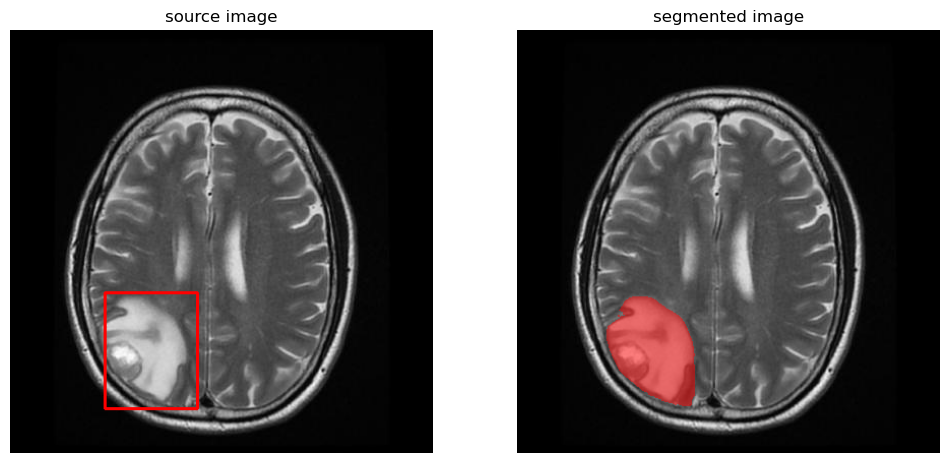

In [139]:
EXAMPLE_IMAGE_NAME = random.choice(IMAGES)
EXAMPLE_IMAGE_PATH = os.path.join(dataset.location, DATA_SET_SUBDIRECTORY, EXAMPLE_IMAGE_NAME)

# load dataset annotations
annotations = COCOJsonUtility.get_annotations_by_image_path(coco_data=coco_data, image_path=EXAMPLE_IMAGE_NAME)
ground_truth = COCOJsonUtility.annotations2detections(annotations=annotations)

# small hack - coco numerate classes from 1, model from 0 + we drop first redundant class from coco json
ground_truth.class_id = ground_truth.class_id - 1

# load image
image_bgr = cv2.imread(EXAMPLE_IMAGE_PATH)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# initiate annotator
box_annotator = sv.BoxAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)
mask_annotator = sv.MaskAnnotator(color=sv.Color.RED, color_lookup=sv.ColorLookup.INDEX)

# annotate ground truth
annotated_frame_ground_truth = box_annotator.annotate(scene=image_bgr.copy(), detections=ground_truth)

# run SAM inference
mask_predictor.set_image(image_rgb)

masks, scores, logits = mask_predictor.predict(
    box=ground_truth.xyxy[0],
    multimask_output=True
)

detections = sv.Detections(
    xyxy=sv.mask_to_xyxy(masks=masks),
    mask=masks
)
detections = detections[detections.area == np.max(detections.area)]

annotated_image = mask_annotator.annotate(scene=image_bgr.copy(), detections=detections)

sv.plot_images_grid(
    images=[annotated_frame_ground_truth, annotated_image],
    grid_size=(1, 2),
    titles=['source image', 'segmented image']
)

## 🏆 Congratulations

### Learning Resources

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.